In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerPatch
import networkx as nx

In [ ]:
N = 8
M = 12
robot_pos = np.random.uniform(-1,1,(N,2)) # positions
task_pos = np.random.uniform(-1,1,(M,2))
theta = 0.5


def c(ri, pj):
    return np.linalg.norm(ri - pj)

def threshold_assign(robot_pos, task_pos, theta, eps=1e-7):
    N = len(robot_pos)
    M = len(task_pos)

    # Step 1: Each robot chooses j* by threshold/max rule
    pref = np.zeros(N, dtype=int)
    for i in range(N):
        s_i = np.zeros(M)
        for j in range(M):
            s_i[j] = 1 / (c(robot_pos[i], task_pos[j]) + eps)

        pref[i] = np.argmax(s_i)        # j*

    # Step 2: Resolve conflicts: if multiple choose same j,
    # keep only robot with minimum c(i,j)
    #assignments = -np.ones(N, dtype=int)   # -1 = unassigned

   # for j in range(M):
    #    robots_want_j = np.where(pref == j)[0]

     #   if len(robots_want_j) == 1:
            # Only one robot chose task j → assign directly
      #      assignments[robots_want_j[0]] = j
      #  elif len(robots_want_j) > 1:
            # Multiple robots want j → choose minimum cost
       #     costs = np.array([c(robot_pos[i], task_pos[j]) for i in robots_want_j])
       #     winner_idx = robots_want_j[np.argmin(costs)]
        #    assignments[winner_idx] = j
            # all other robots remain unassigned (=-1)

    return pref

In [158]:
import numpy as np

N = 8
M = 12
robot_pos = np.random.uniform(-1,1,(N,2))
task_pos  = np.random.uniform(-1,1,(M,2))   # FIXED

def c(ri, pj):
    return np.linalg.norm(ri - pj)


def threshold_assign(robot_pos, task_pos, theta, eps=1e-9):
    N = len(robot_pos)
    M = len(task_pos)

    # Step 1: robots compute their preferred task j*
    pref = -np.ones(N, int)   # start unassigned
    
    for i in range(N):
        s_i = np.zeros(M)
        for j in range(M):
            s_i[j] = 1 / (c(robot_pos[i], task_pos[j]) + eps)

        j_star = np.argmax(s_i)
        if s_i[j_star] >= theta:
       #     print(s_i[j_star])
            pref[i] = j_star         # robot commits tentatively
        else:
            pref[i]=-1

    # Step 2: conflict resolution
    assignments = -np.ones(N, int)

    for j in range(M):
        robots = np.where(pref == j)[0] # get set of robots assigned to task j
        if len(robots) == 1: # if one robot is assigned we are good
            assignments[robots[0]] = j

        elif len(robots) > 1:
            # if multiple assigned to a task we have to break the tie
            costs = np.array([c(robot_pos[i], task_pos[j]) for i in robots])
            winner = robots[np.argmin(costs)]
            assignments[winner] = j
            # losers remain -1

    return assignments

In [159]:
assignments = threshold_assign(robot_pos, task_pos,theta)
print(assignments)

[-1 -1 -1 -1 -1 -1 -1 -1]


In [160]:
def market_assign(robot_pos, task_pos):
    N = len(robot_pos)
    M = len(task_pos)

    # cost matrix B[i,j] = c(i,j)
    B = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            B[i, j] = c(robot_pos[i], task_pos[j])

    # assignments by task: task j assigned to robot i
    assignments = -np.ones(N,int)

    for i in range(N):
        assignments[i] = np.argmin(B[i, :])

    return assignments


market_assign(robot_pos,task_pos)

array([ 0,  6, 10,  0,  4,  4,  3,  0])

In [161]:
a= np.where(np.array([1,1,2,4]) == 1)[0]
print(a)

[0 1]


In [162]:
K = 50
Ctot_thresh = np.zeros(K)
Ctot_market = np.zeros(K)
unassigned_thresh = np.zeros(K)
unassigned_market = np.zeros(K)
N = 8
M = 12
theta = 2
def get_Ctot(assignments, robot_pos, task_pos):
    N = len(robot_pos)
    C_tot=0.0
    for i in range(N):
        assignment = assignments[i]
        if assignment != -1:
            C_tot += c(robot_pos[i], task_pos[assignments[i]])
        else:
            pass
    return C_tot
for k in range(K):
    robot_pos = np.random.uniform(-1,1,(N,2))
    task_pos  = np.random.uniform(-1,1,(M,2))
    thresh_assignments = threshold_assign(robot_pos, task_pos, theta, eps=1e-7)
    market_assignments =  market_assign(robot_pos, task_pos)
    unassigned_market[k] =  len(market_assignments[market_assignments== -1])
    unassigned_thresh[k] = len(thresh_assignments[thresh_assignments == -1])
    Ctot_thresh[k] = get_Ctot(thresh_assignments,robot_pos,task_pos)
    Ctot_market[k] = get_Ctot(market_assignments,robot_pos,task_pos)


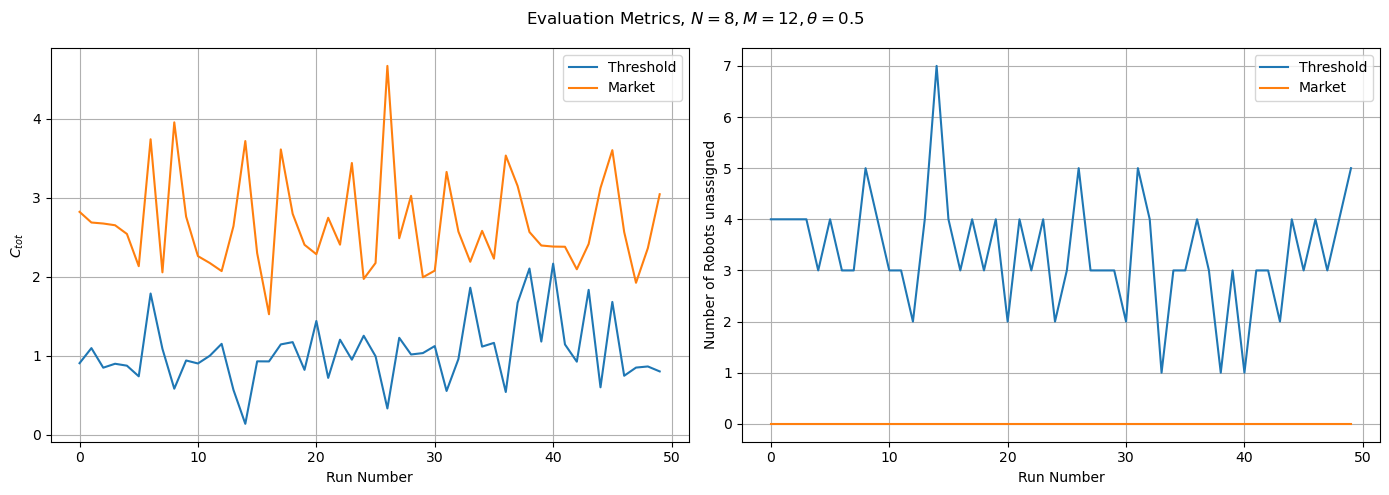

In [163]:
fig, ax = plt.subplots(1,2,figsize =  (14,5))

ax[0].plot(Ctot_thresh, label = "Threshold")
ax[0].plot(Ctot_market, label = "Market")
ax[0].grid()
ax[0].set_xlabel("Run Number")
ax[0].set_ylabel(r"$C_{tot}$")
ax[0].legend()

ax[1].plot(unassigned_thresh, label = "Threshold")
ax[1].plot(unassigned_market, label = "Market")
ax[1].set_xlabel("Run Number")
ax[1].set_ylabel("Number of Robots unassigned")
ax[1].grid()
ax[1].legend()

plt.suptitle(r"Evaluation Metrics, $N=8, M = 12, \theta = 0.5$")
plt.tight_layout()
plt.show()

In [164]:
thetas = np.linspace(0,15,50)
Ctot_thresh_avg = np.zeros(len(thetas))
Ctot_market_avg = np.zeros(len(thetas))
unassigned_thresh_avg = np.zeros(len(thetas))
unassigned_market_avg = np.zeros(len(thetas))

for i, theta in enumerate(thetas):
    Ctot_thresh = np.zeros(K)
    Ctot_market = np.zeros(K)
    unassigned_thresh = np.zeros(K)
    unassigned_market = np.zeros(K)
    N = 8
    M = 12

    for k in range(K):
        robot_pos = np.random.uniform(-1,1,(N,2))
        task_pos  = np.random.uniform(-1,1,(M,2))
        thresh_assignments = threshold_assign(robot_pos, task_pos, theta, eps=1e-7)
        market_assignments =  market_assign(robot_pos, task_pos)
        unassigned_market[k] =  len(market_assignments[market_assignments== -1])
        unassigned_thresh[k] = len(thresh_assignments[thresh_assignments == -1])
        Ctot_thresh[k] = get_Ctot(thresh_assignments,robot_pos,task_pos)
        Ctot_market[k] = get_Ctot(market_assignments,robot_pos,task_pos)
    
    Ctot_thresh_avg[i]= np.mean(Ctot_thresh)
    Ctot_market_avg[i] = np.mean(Ctot_market)
    unassigned_thresh_avg[i] = np.mean(unassigned_thresh)
    unassigned_market_avg[i] = np.mean(unassigned_market)


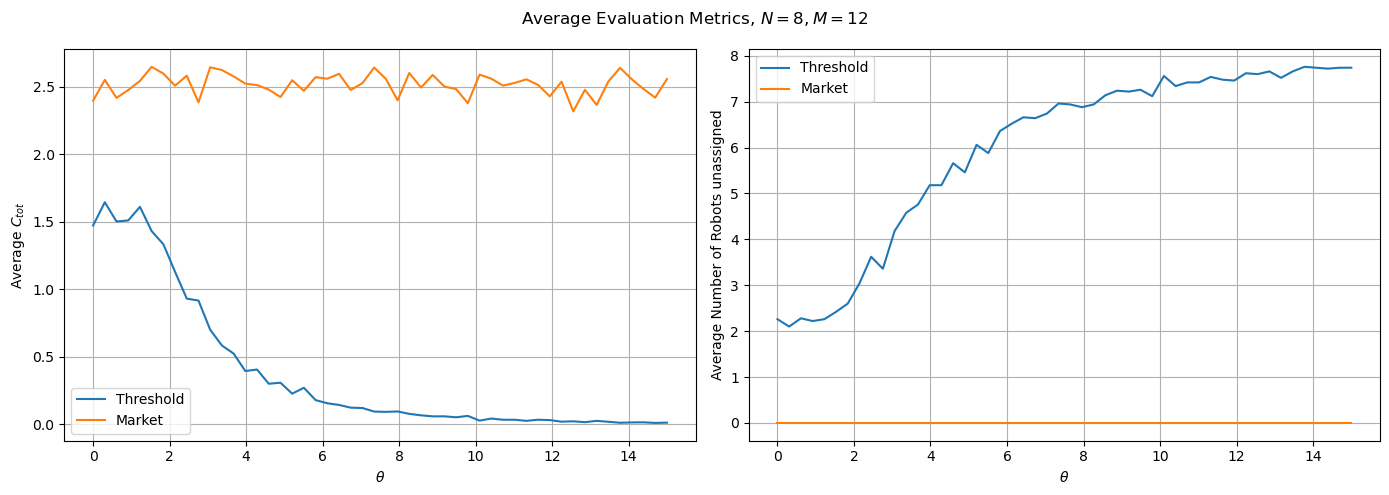

In [165]:
fig, ax = plt.subplots(1,2,figsize =  (14,5))

ax[0].plot(thetas,Ctot_thresh_avg, label = "Threshold")
ax[0].plot(thetas,Ctot_market_avg, label = "Market")
ax[0].grid()
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel(r"Average $C_{tot}$")
ax[0].legend()

ax[1].plot(thetas,unassigned_thresh_avg, label = "Threshold")
ax[1].plot(thetas,unassigned_market_avg, label = "Market")
ax[1].set_xlabel(r"$\theta$")
ax[1].set_ylabel("Average Number of Robots unassigned")
ax[1].grid()
ax[1].legend()

plt.suptitle(r"Average Evaluation Metrics, $N=8, M = 12$")
plt.tight_layout()
plt.show()